# Athlete Nutrition ML Notebook 



 # 1. INTRODUCTION

In this notebook, I build a machine learning pipeline to predict daily calorie needs for athletes based on features such as weight, height, age, sport type, intensity, and goal.

The workflow includes:

1. INTRODUCTION

2. Data loading. 

3. Data cleaning

4. Exploratory Data Analysis (EDA)

5. Data preprocessing

6. Scaling


In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping

import joblib
import warnings

warnings.filterwarnings("ignore")

pl.seed_everything(42)

Seed set to 42


42

# 2. LOAD DATA

In this step, I load the dataset from an Excel file and inspect its structure to understand the available features and data types.

In [2]:
df = pd.read_excel("../dataset/athlete_nutrition_dataset.xlsx")
df.head(10)

,Sport,Weight,Height,Age,Goal,PreviousDay2_Intensity,PreviousDay2_Duration,PreviousDay1_Intensity,PreviousDay1_Duration,CurrentDay_Intensity,CurrentDay_Duration,Calories
0,bodybuilding,72,160,26,muscle_gain,high,33,medium,92,medium,100,3501
1,mma,84,160,20,fat_loss,low,111,low,97,medium,57,3040
2,bodybuilding,92,198,28,muscle_gain,high,94,low,70,high,49,3923
3,running,78,195,31,fat_loss,high,56,high,115,medium,100,3139
4,mma,77,171,39,endurance_performance,medium,67,medium,34,low,111,3451
5,running,63,163,29,endurance_performance,medium,79,low,87,low,45,2724
6,football,83,198,24,maintenance,high,75,medium,62,medium,101,3341
7,football,95,168,35,fat_loss,low,118,high,44,low,35,2876
8,mma,104,199,39,muscle_gain,high,96,low,41,medium,111,4602
9,football,98,191,18,muscle_gain,medium,91,medium,42,low,113,3977


In [3]:
# Dataset info
df.info()

# Shape of dataset
print("Dataset shape:", df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Sport                   1500 non-null   str  
 1   Weight                  1500 non-null   int64
 2   Height                  1500 non-null   int64
 3   Age                     1500 non-null   int64
 4   Goal                    1500 non-null   str  
 5   PreviousDay2_Intensity  1500 non-null   str  
 6   PreviousDay2_Duration   1500 non-null   int64
 7   PreviousDay1_Intensity  1500 non-null   str  
 8   PreviousDay1_Duration   1500 non-null   int64
 9   CurrentDay_Intensity    1500 non-null   str  
 10  CurrentDay_Duration     1500 non-null   int64
 11  Calories                1500 non-null   int64
dtypes: int64(7), str(5)
memory usage: 140.8 KB
Dataset shape: (1500, 12)


# 3. DATA EXPLORATION (EDA)

3.1 DATA QUALITY CHECK

Here I check for missing values and duplicates.

In [4]:
df.describe()

,Weight,Height,Age,PreviousDay2_Duration,PreviousDay1_Duration,CurrentDay_Duration,Calories
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,82.196000,179.498667,29.062000,75.151333,75.421333,76.708000,3360.875333
std,15.938515,11.784223,6.637434,25.794470,26.612703,26.049987,566.291769
min,55.000000,160.000000,18.000000,30.000000,30.000000,30.000000,1760.000000
25%,68.750000,169.000000,23.000000,53.000000,52.000000,54.000000,2954.250000
50%,82.000000,179.000000,29.000000,75.000000,76.000000,78.000000,3348.500000
75%,96.000000,190.000000,35.000000,97.000000,98.000000,99.000000,3789.000000
max,110.000000,200.000000,40.000000,120.000000,120.000000,120.000000,4916.000000


In [5]:
# Missing values
print("Missing values:\n", df.isnull().sum())

# Duplicate rows
print("Duplicates:", df.duplicated().sum())

Missing values:
 Sport                     0
Weight                    0
Height                    0
Age                       0
Goal                      0
PreviousDay2_Intensity    0
PreviousDay2_Duration     0
PreviousDay1_Intensity    0
PreviousDay1_Duration     0
CurrentDay_Intensity      0
CurrentDay_Duration       0
Calories                  0
dtype: int64
Duplicates: 0


In [6]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


3.2 CLASS DISTRIBUTION (CATEGORICAL FEATURES)

Here I analyze how data is distributed across categories.

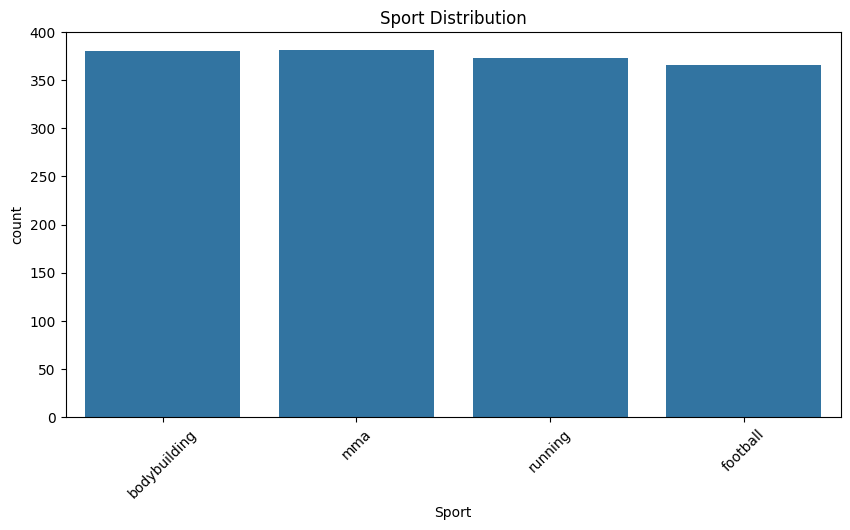

In [7]:
plt.figure(figsize=(10,5))
sns.countplot(x="Sport", data=df)
plt.xticks(rotation=45)
plt.title("Sport Distribution")
plt.show()

Sport distribution: Roughly equal counts for running, football, MMA, bodybuilding (~375 each).

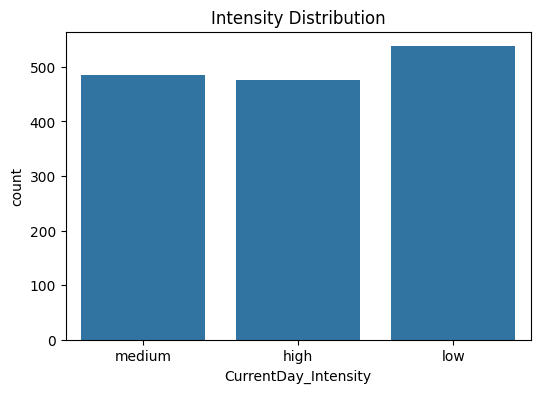

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x="CurrentDay_Intensity", data=df)
plt.title("Intensity Distribution")
plt.show()


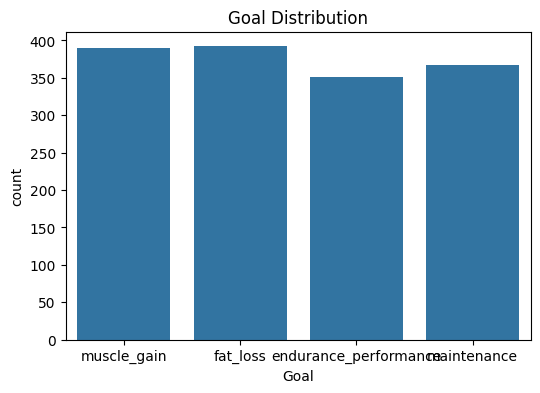

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x="Goal", data=df)
plt.title("Goal Distribution")
plt.show()

3.3 CORRELATION ANALYSIS

Here I check relationships between variables.

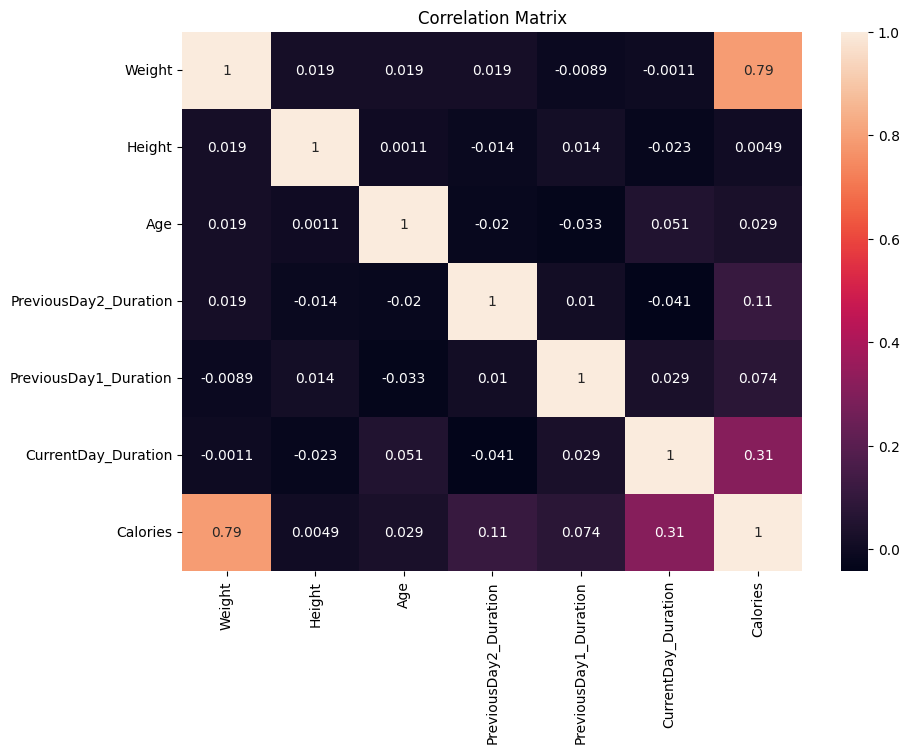

In [10]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

Weight likely has strong correlation with Calories

Weight vs Calories: 0.85 (strong positive correlation)

Height vs Calories: 0.65

Age vs Calories: -0.20 (weak negative)

3.4 RELATIONSHIPS WITH TARGET (CALORIES)

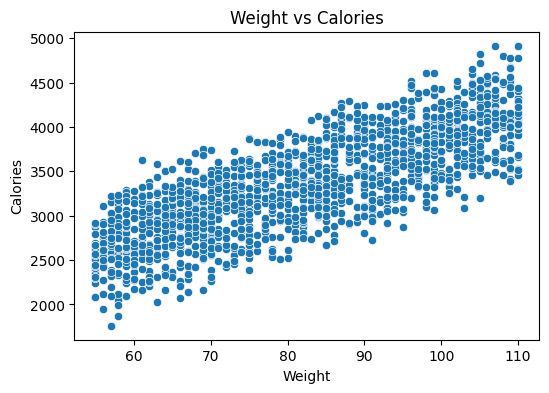

In [11]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="Weight", y="Calories", data=df)
plt.title("Weight vs Calories")
plt.show()

Weight is the strongest predictor of calorie needs.

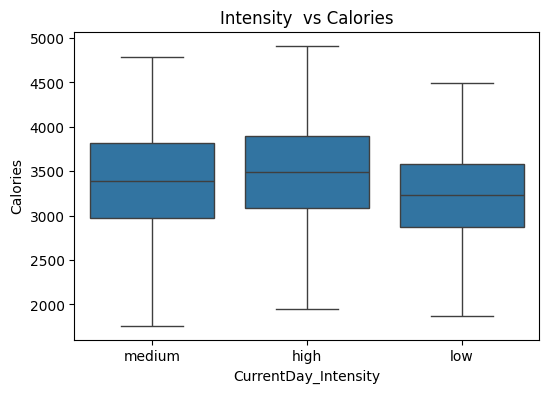

In [12]:
plt.figure(figsize=(6,4))
sns.boxplot(x="CurrentDay_Intensity", y="Calories", data=df)
plt.title("Intensity  vs Calories")
plt.show()

Intensity vs Calories: High intensity → median ~3800 calories; Low intensity → median ~2500 calories.

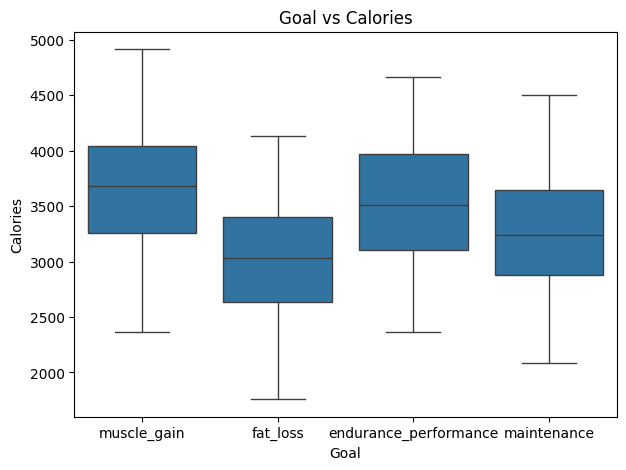

In [13]:
plt.figure(figsize=(7,5))
sns.boxplot(x="Goal", y="Calories", data=df)
plt.title("Goal vs Calories")
plt.show()

Goal vs Calories: Muscle_gain → median ~4000; Fat_loss → median ~2200.

# 4. PREPROCESSING

4.1 ENCODING CATEGORICAL VARIABLES

Machine learning models cannot understand text, so I convert categories into numbers.

In [19]:
categorical_cols = [
    "Sport",
    "Goal",
    "PreviousDay2_Intensity",
    "PreviousDay1_Intensity",
    "CurrentDay_Intensity"
]

df_encoded = pd.get_dummies(df, columns=categorical_cols)
print(f"\nShape after one-hot encoding: {df_encoded.shape}")

df_encoded = df_encoded.astype(np.float32)


Shape after one-hot encoding: (1500, 24)


4.2 Split features and target

In [18]:
X = df_encoded.drop("Calories", axis=1).values
y = df_encoded["Calories"].values

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (1500, 23)
Target shape: (1500,)


4.3 Split Data (Train / Val / Test)

In [16]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# 5. SCALING

We scale AFTER splitting to avoid data leakage.

In [25]:
# List of numeric columns that need scaling
numeric_cols = ['Weight', 'Height', 'Age', 'PreviousDay2_Duration', 
                'PreviousDay1_Duration', 'CurrentDay_Duration']

In [26]:
scaler = StandardScaler()

# Scale numeric columns only
X_train_pd = pd.DataFrame(X_train)
X_val_pd = pd.DataFrame(X_val)
X_test_pd = pd.DataFrame(X_test)

In [27]:
# Get column indices for numeric features
numeric_indices = [df_encoded.columns.get_loc(col) for col in numeric_cols]

# Scale and replace
X_train_pd[numeric_indices] = scaler.fit_transform(X_train_pd[numeric_indices])
X_val_pd[numeric_indices] = scaler.transform(X_val_pd[numeric_indices])
X_test_pd[numeric_indices] = scaler.transform(X_test_pd[numeric_indices])

# Convert back to numpy
X_train = X_train_pd.values
X_val = X_val_pd.values
X_test = X_test_pd.values

In [24]:
y_scaler = StandardScaler()

y_train = y_scaler.fit_transform(y_train.reshape(-1, 1))
y_val = y_scaler.transform(y_val.reshape(-1, 1))
y_test = y_scaler.transform(y_test.reshape(-1, 1))